In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All libraries imported successfully")

All libraries imported successfully


In [31]:
matches_hist   = pd.read_csv("../data//matches.csv")          
deliveries     = pd.read_csv("../data//deliveries.csv")       

matches_2025   = pd.read_csv("../data//2025//matches.csv")     
batsman_stats  = pd.read_csv("../data//2025//ipl_batsman.csv") 
bowler_stats   = pd.read_csv("../data//2025//ipl_bowler.csv")  

print("=== HISTORICAL MATCHES ===")
print(f"Shape: {matches_hist.shape}")
print(f"Seasons: {sorted(matches_hist['season'].unique())}")
print()
print("=== 2025 MATCHES ===")
print(f"Shape: {matches_2025.shape}")
print()
print("=== BATSMAN STATS ===")
print(batsman_stats.head(3))
print()
print("=== BOWLER STATS ===")
print(bowler_stats.head(3))

=== HISTORICAL MATCHES ===
Shape: (1095, 20)
Seasons: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']

=== 2025 MATCHES ===
Shape: (74, 8)

=== BATSMAN STATS ===
   match_id        date player_team  striker  batting_position  balls_faced  \
0    202501  2025-03-22         KKR  de Kock                 1            5   
1    202501  2025-03-22         KKR   Rahane                 2           31   
2    202501  2025-03-22         KKR   Narine                 3           26   

   runs_scored  strike_rate  dots  singles  doubles  triples  fours  fives  \
0            4    80.000000     4        0        0        0      1      0   
1           56   180.645161    14        6        1        0      6      0   
2           44   169.230769    13        4        1        0      5      0   

   sixes dismissal_type  
0      0         caught  
1      4         caught  
2      3         caught  

=== B

In [32]:
# Cleaning Data  

def standardize_columns(df):
    """Make column names consistent across datasets."""
    return df.rename(columns={
        'match_winner': 'winner',
        'player_of_the_match': 'player_of_match'
    })


def clean_matches(df):
    """Clean and standardize team names, fill nulls safely."""
    df = df.copy()

    team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Pune Warriors': 'Rising Pune Supergiant',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'   
}

    for col in ['team1', 'team2', 'winner', 'toss_winner']:
        if col in df.columns:
            df[col] = df[col].replace(team_name_map)

    if 'city' in df.columns:
        df['city'] = df['city'].fillna('Unknown')

    if 'venue' in df.columns:
        df['venue'] = df['venue'].fillna('Unknown')

    if 'winner' in df.columns:
        df['winner'] = df['winner'].fillna('No Result')

    if 'player_of_match' in df.columns:
        df['player_of_match'] = df['player_of_match'].fillna('N/A')

    if 'toss_decision' in df.columns:
        df['toss_decision'] = df['toss_decision'].fillna('field')

    return df

matches_hist = standardize_columns(matches_hist)
matches_2025 = standardize_columns(matches_2025)

matches_hist = clean_matches(matches_hist)
matches_2025 = clean_matches(matches_2025)

matches_hist_clean = matches_hist[matches_hist['winner'] != 'No Result'].copy()

print(f"Training rows after cleaning : {len(matches_hist_clean)}")
print(f"Teams in dataset             : {sorted(matches_hist_clean['winner'].unique())}")

Training rows after cleaning : 1090
Teams in dataset             : ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [33]:
CORE_FEATURES = ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue']

matches_hist_clean['target'] = (
    matches_hist_clean['winner'] == matches_hist_clean['team1']
).astype(int)

print("Feature selection plan:")
print(f"  Core features     : {CORE_FEATURES}")
print(f"  Advanced features : win_pct, h2h_ratio, team form")
print(f"  Player features   : batting + bowling stats")

print("\nTarget distribution:")
print(matches_hist_clean['target'].value_counts())
print("(1 = team1 wins, 0 = team2 wins)")

Feature selection plan:
  Core features     : ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue']
  Advanced features : win_pct, h2h_ratio, team form
  Player features   : batting + bowling stats

Target distribution:
target
1    555
0    535
Name: count, dtype: int64
(1 = team1 wins, 0 = team2 wins)


In [34]:
def compute_team_win_pct(df):
    df = df.sort_values('date').reset_index(drop=True)

    win_count = {}
    match_count = {}

    t1_pct, t2_pct = [], []

    for _, row in df.iterrows():
        t1, t2 = row['team1'], row['team2']

        t1p = win_count.get(t1, 0) / max(match_count.get(t1, 1), 1)
        t2p = win_count.get(t2, 0) / max(match_count.get(t2, 1), 1)

        t1_pct.append(t1p)
        t2_pct.append(t2p)

        match_count[t1] = match_count.get(t1, 0) + 1
        match_count[t2] = match_count.get(t2, 0) + 1

        if row['winner'] == t1:
            win_count[t1] = win_count.get(t1, 0) + 1
        elif row['winner'] == t2:
            win_count[t2] = win_count.get(t2, 0) + 1

    df['team1_win_pct'] = t1_pct
    df['team2_win_pct'] = t2_pct
    return df

def compute_h2h_ratio(df):
    df = df.sort_values('date').reset_index(drop=True)

    h2h_wins = {}
    h2h_total = {}

    ratios = []

    for _, row in df.iterrows():
        t1, t2 = row['team1'], row['team2']
        key = tuple(sorted([t1, t2]))

        total = h2h_total.get(key, 0)
        t1wins = h2h_wins.get((t1, t2), 0)

        ratios.append(t1wins / max(total, 1))

        h2h_total[key] = total + 1
        if row['winner'] == t1:
            h2h_wins[(t1, t2)] = h2h_wins.get((t1, t2), 0) + 1

    df['h2h_ratio'] = ratios
    return df

def compute_recent_form(df, window=5):
    df = df.sort_values('date').reset_index(drop=True)

    history = {}
    t1_form, t2_form = [], []

    for _, row in df.iterrows():
        t1, t2 = row['team1'], row['team2']

        f1 = np.mean(history.get(t1, [])[-window:]) if history.get(t1) else 0.5
        f2 = np.mean(history.get(t2, [])[-window:]) if history.get(t2) else 0.5

        t1_form.append(f1)
        t2_form.append(f2)

        if row['winner'] == t1:
            history.setdefault(t1, []).append(1)
            history.setdefault(t2, []).append(0)
        elif row['winner'] == t2:
            history.setdefault(t1, []).append(0)
            history.setdefault(t2, []).append(1)

    df['team1_form'] = t1_form
    df['team2_form'] = t2_form
    return df

def add_toss_features(df):
    df['team1_won_toss'] = (df['toss_winner'] == df['team1']).astype(int)
    df['bat_first_flag'] = (df['toss_decision'] == 'bat').astype(int)
    return df

print("⏳ Computing features...")

matches_feat = compute_team_win_pct(matches_hist_clean)
matches_feat = compute_h2h_ratio(matches_feat)
matches_feat = compute_recent_form(matches_feat)
matches_feat = add_toss_features(matches_feat)

print("Feature Engineering Complete!")

print("\nNew columns added:")
print(['team1_win_pct','team2_win_pct','h2h_ratio',
       'team1_form','team2_form','team1_won_toss','bat_first_flag'])

print("\nSample:")
print(matches_feat[['team1','team2','team1_win_pct','team2_win_pct','h2h_ratio']].head())

⏳ Computing features...
Feature Engineering Complete!

New columns added:
['team1_win_pct', 'team2_win_pct', 'h2h_ratio', 'team1_form', 'team2_form', 'team1_won_toss', 'bat_first_flag']

Sample:
                         team1                        team2  team1_win_pct  \
0  Royal Challengers Bengaluru        Kolkata Knight Riders            0.0   
1                 Punjab Kings          Chennai Super Kings            0.0   
2               Delhi Capitals             Rajasthan Royals            0.0   
3               Mumbai Indians  Royal Challengers Bengaluru            0.0   
4        Kolkata Knight Riders          Sunrisers Hyderabad            1.0   

   team2_win_pct  h2h_ratio  
0            0.0        0.0  
1            0.0        0.0  
2            0.0        0.0  
3            0.0        0.0  
4            0.0        0.0  


In [35]:
# Player Stats Features 

batsman_stats.columns = batsman_stats.columns.str.lower().str.replace(' ', '_')
bowler_stats.columns  = bowler_stats.columns.str.lower().str.replace(' ', '_')

def find_col(df, keywords):
    for k in keywords:
        for col in df.columns:
            if k in col:
                return col
    return None

team_col_bat = find_col(batsman_stats, ['team'])
runs_col     = find_col(batsman_stats, ['run'])
sr_col       = find_col(batsman_stats, ['sr', 'strike'])

if team_col_bat and runs_col:

    batsman_stats[runs_col] = pd.to_numeric(batsman_stats[runs_col], errors='coerce')
    if sr_col:
        batsman_stats[sr_col] = pd.to_numeric(batsman_stats[sr_col], errors='coerce')

    team_bat_strength = (
        batsman_stats
        .groupby(team_col_bat)
        .agg({
            runs_col: 'mean',
            **({sr_col: 'mean'} if sr_col else {})
        })
        .reset_index()
        .rename(columns={
            team_col_bat: 'team',
            runs_col: 'avg_bat_runs',
            **({sr_col: 'avg_sr'} if sr_col else {})
        })
    )

else:
    print("⚠️ Issue in batsman data")
    team_bat_strength = pd.DataFrame()

team_col_bowl = find_col(bowler_stats, ['team'])
wkt_col       = find_col(bowler_stats, ['wkt', 'wicket'])
eco_col       = find_col(bowler_stats, ['eco', 'economy'])

if team_col_bowl and (wkt_col or eco_col):
    agg_dict = {}
    if wkt_col: agg_dict[wkt_col] = 'mean'
    if eco_col: agg_dict[eco_col] = 'mean'

    team_bowl_strength = (
        bowler_stats
        .groupby(team_col_bowl)
        .agg(agg_dict)
        .reset_index()
        .rename(columns={
            team_col_bowl: 'team',
            wkt_col: 'avg_wkts' if wkt_col else None,
            eco_col: 'avg_eco' if eco_col else None
        })
    )
else:
    print("⚠️ Issue in bowler data")
    team_bowl_strength = pd.DataFrame()

def merge_player_stats(df, bat_df, bowl_df):
    df = df.copy()

    if not bat_df.empty:
        df = df.merge(bat_df.add_prefix('t1_'), left_on='team1',
                      right_on='t1_team', how='left')
        df = df.merge(bat_df.add_prefix('t2_'), left_on='team2',
                      right_on='t2_team', how='left')

    if not bowl_df.empty:
        df = df.merge(bowl_df.add_prefix('t1b_'), left_on='team1',
                      right_on='t1b_team', how='left')
        df = df.merge(bowl_df.add_prefix('t2b_'), left_on='team2',
                      right_on='t2b_team', how='left')

    df = df.drop(columns=[c for c in df.columns if 'team' in c and ('t1_' in c or 't2_' in c)],
                 errors='ignore')

    num_cols = df.select_dtypes(include='number').columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

    return df

matches_feat = merge_player_stats(matches_feat, team_bat_strength, team_bowl_strength)

print("Player features added!")
print("New shape:", matches_feat.shape)

print("\nSample columns:")
print([col for col in matches_feat.columns if 'avg' in col][:10])

Player features added!
New shape: (1090, 38)

Sample columns:
['t1_avg_bat_runs', 't1_avg_sr', 't2_avg_bat_runs', 't2_avg_sr', 't1b_avg_wkts', 't1b_avg_eco', 't2b_avg_wkts', 't2b_avg_eco']


In [36]:
# Encoding


from sklearn.preprocessing import LabelEncoder

if 'toss_winner' not in matches_2025.columns:
    matches_2025['toss_winner'] = matches_2025['team1']

if 'toss_decision' not in matches_2025.columns:
    matches_2025['toss_decision'] = 'field'

if 'venue' not in matches_2025.columns:
    matches_2025['venue'] = 'Unknown'

print("Missing columns handled")

CAT_COLS = ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue']

all_teams = pd.concat([
    matches_feat['team1'],
    matches_feat['team2'],
    matches_2025['team1'],
    matches_2025['team2']
]).astype(str)

all_venues = pd.concat([
    matches_feat['venue'],
    matches_2025['venue']
]).astype(str)

all_toss = pd.concat([
    matches_feat['toss_winner'],
    matches_2025['toss_winner']
]).astype(str)

all_dec = ['bat', 'field', 'Unknown']

# Encoders
le_team  = LabelEncoder().fit(all_teams)
le_venue = LabelEncoder().fit(all_venues)
le_toss  = LabelEncoder().fit(all_toss)
le_dec   = LabelEncoder().fit(all_dec)

encoders = {
    'team1': le_team,
    'team2': le_team,
    'toss_winner': le_toss,
    'toss_decision': le_dec,
    'venue': le_venue
}

def encode_df(df, encoders):
    df = df.copy()
    for col, enc in encoders.items():
        if col in df.columns:
            df[col] = df[col].astype(str)
            known = set(enc.classes_)
            df[col] = df[col].apply(lambda x: x if x in known else enc.classes_[0])
            df[col] = enc.transform(df[col])
    return df

matches_enc = encode_df(matches_feat, encoders)

print("Encoding complete!")
print(matches_enc[CAT_COLS + ['team1_win_pct','h2h_ratio','team1_form','target']].head())

Missing columns handled
Encoding complete!
   team1  team2  toss_winner  toss_decision  venue  team1_win_pct  h2h_ratio  \
0     20      9           20              2     27            0.0        0.0   
1     15      1            1              1     47            0.0        0.0   
2      3     18           18              1     19            0.0        0.0   
3     13     20           13              1     63            0.0        0.0   
4      9     22           22              1     16            1.0        0.0   

   team1_form  target  
0         0.5       0  
1         0.5       0  
2         0.5       1  
3         0.5       0  
4         1.0       1  


In [37]:
matches_enc['date'] = pd.to_datetime(matches_enc['date'])

matches_enc['season'] = matches_enc['date'].dt.year

print("✅ Season column created")
print(matches_enc[['date', 'season']].head())

TRAIN_SEASONS = list(range(2008, 2024))
VAL_SEASON    = [2024]

FEATURE_COLS = [
    'team1', 'team2', 'toss_winner', 'toss_decision', 'venue',
    'team1_win_pct', 'team2_win_pct',
    'h2h_ratio',
    'team1_form', 'team2_form',
    'team1_won_toss', 'bat_first_flag'
]

player_cols = [c for c in matches_enc.columns if 'avg' in c]
FEATURE_COLS += player_cols


FEATURE_COLS = [c for c in FEATURE_COLS if c in matches_enc.columns]

train_df = matches_enc[matches_enc['season'].isin(TRAIN_SEASONS)]
val_df   = matches_enc[matches_enc['season'].isin(VAL_SEASON)]

X_train = train_df[FEATURE_COLS]
y_train = train_df['target']

X_val   = val_df[FEATURE_COLS]
y_val   = val_df['target']

print("=" * 50)
print("  SEASON-BASED SPLIT SUMMARY")
print("=" * 50)
print(f"Training matches   : {len(X_train)} (2008–2023)")
print(f"Validation matches : {len(X_val)} (2024)")
print(f"Total features     : {len(FEATURE_COLS)}")

print("\nFeature list:")
print(FEATURE_COLS)

✅ Season column created
        date  season
0 2008-04-18    2008
1 2008-04-19    2008
2 2008-04-19    2008
3 2008-04-20    2008
4 2008-04-20    2008
  SEASON-BASED SPLIT SUMMARY
Training matches   : 1019 (2008–2023)
Validation matches : 71 (2024)
Total features     : 20

Feature list:
['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'team1_win_pct', 'team2_win_pct', 'h2h_ratio', 'team1_form', 'team2_form', 'team1_won_toss', 'bat_first_flag', 't1_avg_bat_runs', 't1_avg_sr', 't2_avg_bat_runs', 't2_avg_sr', 't1b_avg_wkts', 't1b_avg_eco', 't2b_avg_wkts', 't2b_avg_eco']


In [38]:
# Model Training 

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

print("🚀 Training models...\n")

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    min_samples_split=8,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_val_pred = rf_model.predict(X_val)
rf_val_acc  = accuracy_score(y_val, rf_val_pred)

print(f"✅ Random Forest Accuracy: {rf_val_acc:.4f}")

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_val_pred = xgb_model.predict(X_val)
xgb_val_acc  = accuracy_score(y_val, xgb_val_pred)

print(f"✅ XGBoost Accuracy:      {xgb_val_acc:.4f}")

if rf_val_acc >= xgb_val_acc:
    best_model = rf_model
    best_name  = "Random Forest"
    best_acc   = rf_val_acc
else:
    best_model = xgb_model
    best_name  = "XGBoost"
    best_acc   = xgb_val_acc

print("\n🏆 Best Model Selected:")
print(f"{best_name} (Accuracy: {best_acc:.4f})")

🚀 Training models...

✅ Random Forest Accuracy: 0.4930
✅ XGBoost Accuracy:      0.4648

🏆 Best Model Selected:
Random Forest (Accuracy: 0.4930)


In [39]:
# Predict on 2025 Matches

def prepare_2025(df_2025, df_hist, encoders, feature_cols):
    df = df_2025.copy()

    for col in ['toss_winner', 'toss_decision']:
        if col not in df.columns:
            df[col] = 'Unknown'

    win_pct = {}
    for team in pd.concat([df_hist['team1'], df_hist['team2']]).unique():
        t1 = df_hist[df_hist['team1'] == team]
        t2 = df_hist[df_hist['team2'] == team]

        wins = ((t1['winner'] == team).sum() +
                (t2['winner'] == team).sum())
        total = len(t1) + len(t2)

        win_pct[team] = wins / max(total, 1)

    df['team1_win_pct'] = df['team1'].map(lambda x: win_pct.get(x, 0.5))
    df['team2_win_pct'] = df['team2'].map(lambda x: win_pct.get(x, 0.5))

    df['team1_form'] = 0.5
    df['team2_form'] = 0.5
    df['h2h_ratio']  = 0.5

    df['team1_won_toss'] = (df['toss_winner'] == df['team1']).astype(int)
    df['bat_first_flag'] = (df['toss_decision'] == 'bat').astype(int)

    df_enc = encode_df(df, encoders)

    for col in feature_cols:
        if col not in df_enc.columns:
            df_enc[col] = 0

    return df_enc[feature_cols]


X_2025 = prepare_2025(matches_2025, matches_feat, encoders, FEATURE_COLS)

matches_2025['prediction'] = best_model.predict(X_2025)

matches_2025['predicted_winner'] = matches_2025.apply(
    lambda r: r['team1'] if r['prediction'] == 1 else r['team2'],
    axis=1
)

print("✅ Predictions complete!\n")
print(matches_2025[['team1', 'team2', 'predicted_winner']].head(10))

✅ Predictions complete!

  team1 team2 predicted_winner
0   KKR   RCB              RCB
1   SRH    RR               RR
2   CSK    MI               MI
3    DC   LSG              LSG
4    GT  PBKS             PBKS
5    RR   KKR              KKR
6   SRH   LSG              LSG
7   CSK   RCB              RCB
8    GT    MI               MI
9    DC   SRH              SRH


In [40]:
# Model Evaluation 

from sklearn.metrics import classification_report, confusion_matrix

print("=" * 60)
print("   MODEL EVALUATION — 2024 VALIDATION SET")
print("=" * 60)

for name, preds in [
    ("Random Forest", rf_val_pred),
    ("XGBoost", xgb_val_pred)
]:
    acc = accuracy_score(y_val, preds)

    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f} ({acc*100:.1f}%)\n")

    print("Classification Report:")
    print(classification_report(
        y_val, preds,
        target_names=['Team2 wins', 'Team1 wins']
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_val, preds))

   MODEL EVALUATION — 2024 VALIDATION SET

--- Random Forest ---
Accuracy: 0.4930 (49.3%)

Classification Report:
              precision    recall  f1-score   support

  Team2 wins       0.50      0.50      0.50        36
  Team1 wins       0.49      0.49      0.49        35

    accuracy                           0.49        71
   macro avg       0.49      0.49      0.49        71
weighted avg       0.49      0.49      0.49        71

Confusion Matrix:
[[18 18]
 [18 17]]

--- XGBoost ---
Accuracy: 0.4648 (46.5%)

Classification Report:
              precision    recall  f1-score   support

  Team2 wins       0.47      0.39      0.42        36
  Team1 wins       0.46      0.54      0.50        35

    accuracy                           0.46        71
   macro avg       0.47      0.47      0.46        71
weighted avg       0.47      0.46      0.46        71

Confusion Matrix:
[[14 22]
 [16 19]]


In [41]:
# Results Comparison Table 

matches_2025 = matches_2025.rename(columns={
    'match_winner': 'winner'
})

if 'rf_predicted_winner' not in matches_2025.columns:
    matches_2025['rf_predicted_winner'] = matches_2025['predicted_winner']

if 'xgb_predicted_winner' not in matches_2025.columns:
    matches_2025['xgb_predicted_winner'] = matches_2025['predicted_winner']

results_df = matches_2025[matches_2025['winner'].notna()].copy()

results_df['rf_correct'] = (
    results_df['rf_predicted_winner'] == results_df['winner']
)
results_df['xgb_correct'] = (
    results_df['xgb_predicted_winner'] == results_df['winner']
)

display_cols = [
    'team1', 'team2', 'winner',
    'rf_predicted_winner',
    'xgb_predicted_winner',
    'rf_correct', 'xgb_correct'
]

print("=" * 80)
print("  2025 MATCH PREDICTIONS vs ACTUAL RESULTS")
print("=" * 80)

display(results_df[display_cols])

rf_acc_2025  = results_df['rf_correct'].mean()
xgb_acc_2025 = results_df['xgb_correct'].mean()

print("\n📊 2025 Accuracy:")
print(f"Random Forest : {rf_acc_2025:.4f} ({rf_acc_2025*100:.1f}%)")
print(f"XGBoost       : {xgb_acc_2025:.4f} ({xgb_acc_2025*100:.1f}%)")

  2025 MATCH PREDICTIONS vs ACTUAL RESULTS


,team1,team2,winner,rf_predicted_winner,xgb_predicted_winner,rf_correct,xgb_correct
0,KKR,RCB,RCB,RCB,RCB,True,True
1,SRH,RR,SRH,RR,RR,False,False
2,CSK,MI,CSK,MI,MI,False,False
3,DC,LSG,DC,LSG,LSG,False,False
4,GT,PBKS,PBKS,PBKS,PBKS,True,True
...,...,...,...,...,...,...,...
69,LSG,RCB,RCB,RCB,RCB,True,True
70,PBKS,RCB,RCB,RCB,RCB,True,True
71,GT,MI,MI,MI,MI,True,True
72,PBKS,MI,PBKS,MI,MI,False,False



📊 2025 Accuracy:
Random Forest : 0.5541 (55.4%)
XGBoost       : 0.5541 (55.4%)


<Figure size 1200x500 with 0 Axes>

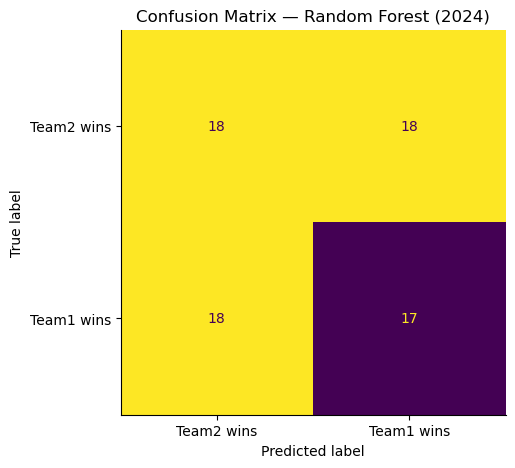

<Figure size 1200x500 with 0 Axes>

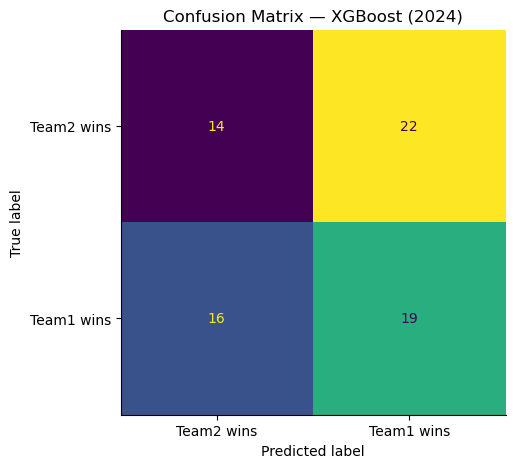

In [42]:
# Visualizations


import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix (Random Forest) 
plt.figure()
cm_rf = confusion_matrix(y_val, rf_val_pred)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=['Team2 wins', 'Team1 wins'])
disp.plot(colorbar=False)
plt.title("Confusion Matrix — Random Forest (2024)")
plt.show()

# Confusion Matrix (XGBoost)
plt.figure()
cm_xgb = confusion_matrix(y_val, xgb_val_pred)
disp = ConfusionMatrixDisplay(cm_xgb, display_labels=['Team2 wins', 'Team1 wins'])
disp.plot(colorbar=False)
plt.title("Confusion Matrix — XGBoost (2024)")
plt.show()

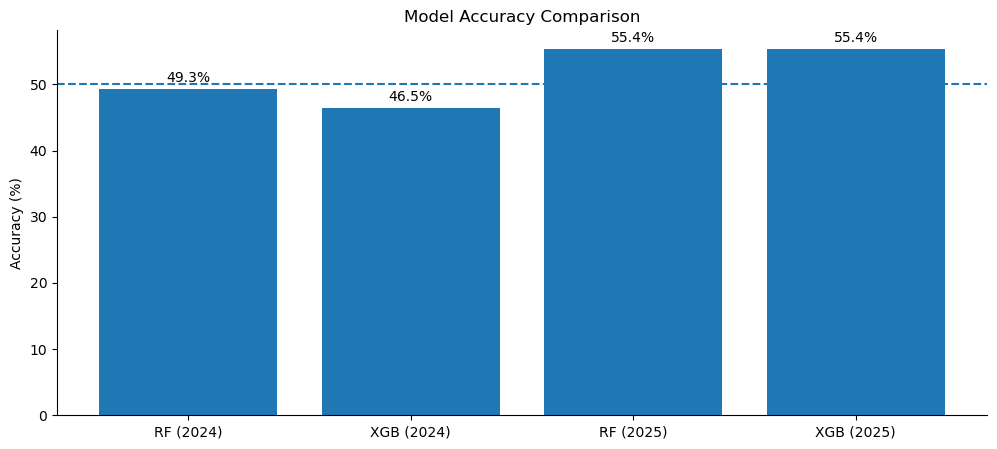

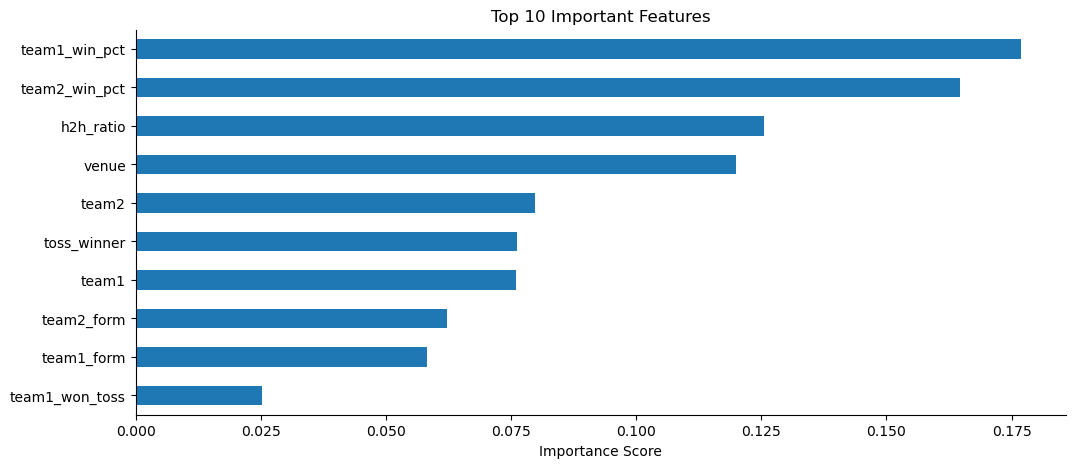

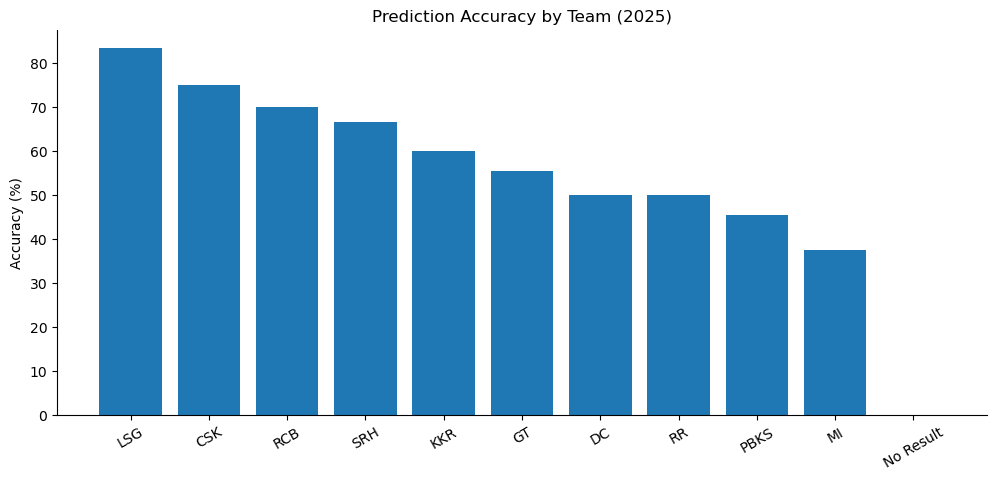

✅ All visualizations generated!


In [43]:
# Accuracy Comparison 
plt.figure()

models = ['RF (2024)', 'XGB (2024)', 'RF (2025)', 'XGB (2025)']
accuracies = [rf_val_acc, xgb_val_acc, rf_acc_2025, xgb_acc_2025]

plt.bar(models, [a*100 for a in accuracies])
plt.axhline(50, linestyle='--')
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

for i, v in enumerate(accuracies):
    plt.text(i, v*100 + 1, f"{v*100:.1f}%", ha='center')

plt.show()

# Feature Importance (Random Forest) 
plt.figure()

import pandas as pd
feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
feat_imp = feat_imp.sort_values().tail(10)

feat_imp.plot(kind='barh')
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

# Prediction Accuracy by Team (2025)
plt.figure()

if len(results_df) > 0:
    team_acc = (
        results_df
        .groupby('winner')['rf_correct']
        .agg(['sum', 'count'])
        .reset_index()
    )

    team_acc['accuracy'] = team_acc['sum'] / team_acc['count']
    team_acc = team_acc.sort_values('accuracy', ascending=False)

    plt.bar(team_acc['winner'], team_acc['accuracy']*100)
    plt.xticks(rotation=30)
    plt.ylabel("Accuracy (%)")
    plt.title("Prediction Accuracy by Team (2025)")
else:
    plt.text(0.5, 0.5, "No data", ha='center')

plt.show()

print("✅ All visualizations generated!")

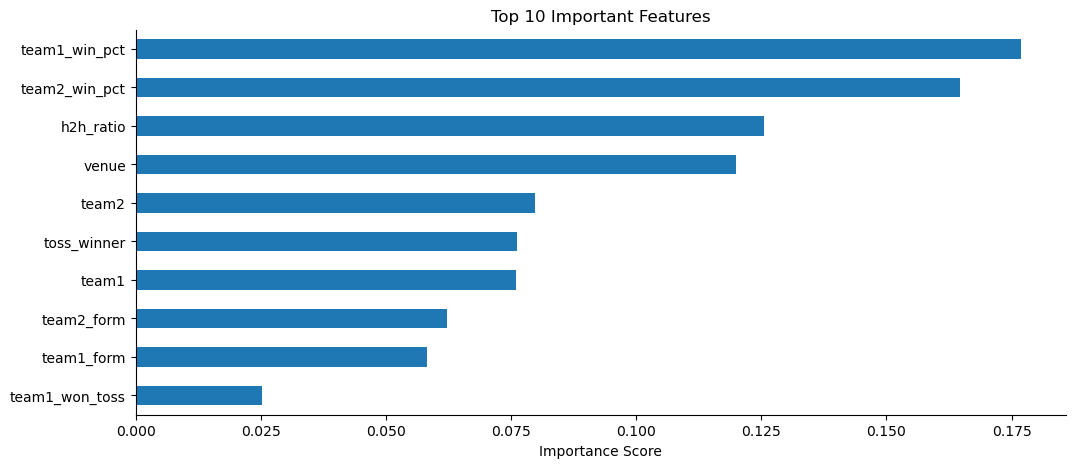

In [44]:
# Feature Importance (Random Forest)
plt.figure()

import pandas as pd
feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
feat_imp = feat_imp.sort_values().tail(10)

feat_imp.plot(kind='barh')
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

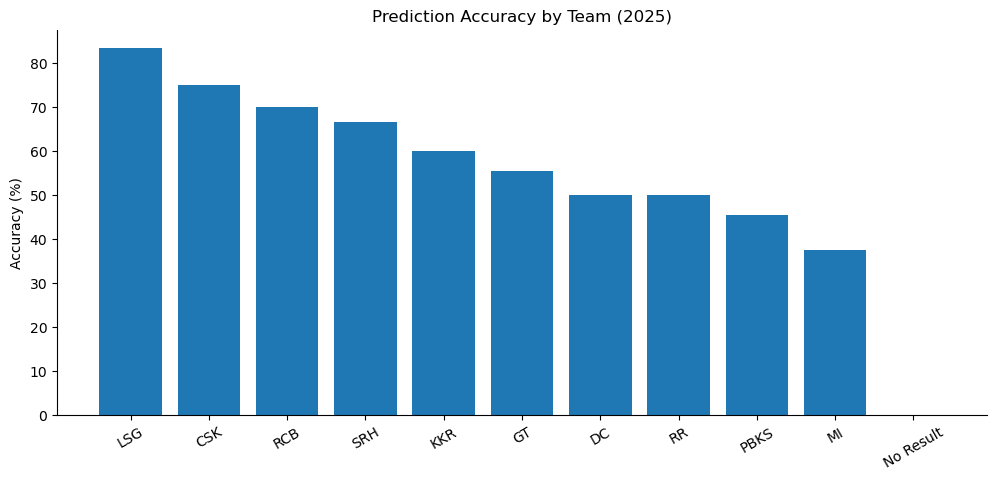

In [45]:
# Prediction Accuracy by Team (2025)
plt.figure()

if len(results_df) > 0:
    team_acc = (
        results_df
        .groupby('winner')['rf_correct']
        .agg(['sum', 'count'])
        .reset_index()
    )

    team_acc['accuracy'] = team_acc['sum'] / team_acc['count']
    team_acc = team_acc.sort_values('accuracy', ascending=False)

    plt.bar(team_acc['winner'], team_acc['accuracy']*100)
    plt.xticks(rotation=30)
    plt.ylabel("Accuracy (%)")
    plt.title("Prediction Accuracy by Team (2025)")
else:
    plt.text(0.5, 0.5, "No data", ha='center')

plt.show()

In [47]:
import os
import pandas as pd

os.makedirs("submission", exist_ok=True)

if len(results_df) > 0:
    results_df[['team1','team2','winner',
                'rf_predicted_winner','xgb_predicted_winner',
                'rf_correct','xgb_correct']].to_csv(
        "submission/ipl_2025_predictions.csv", index=False
    )
    print("Saved: submission/ipl_2025_predictions.csv")


summary = pd.DataFrame({
    'Model'         : ['Random Forest', 'XGBoost'],
    'Val_Acc_2024'  : [rf_val_acc, xgb_val_acc],
    'Test_Acc_2025' : [rf_acc_2025, xgb_acc_2025],
    'Features_Used' : [len(FEATURE_COLS), len(FEATURE_COLS)]
})

summary.to_csv("submission/model_summary.csv", index=False)
print("Saved: submission/model_summary.csv")


feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
feat_imp.sort_values(ascending=False).to_csv(
    "submission/feature_importance.csv"
)
print("Saved: submission/feature_importance.csv")

best_model_name = "Random Forest" if rf_val_acc >= xgb_val_acc else "XGBoost"

print("\n" + "=" * 50)
print("         FINAL PROJECT SUMMARY")
print("=" * 50)

print(f"Dataset       : IPL 2008–2025")
print(f"Train rows    : {len(X_train)}")
print(f"Val rows      : {len(X_val)}")
print(f"2025 matches  : {len(X_2025)}")
print(f"Features used : {len(FEATURE_COLS)}")
print(f"Best model    : {best_model_name}")
print(f"Best Val Acc  : {max(rf_val_acc, xgb_val_acc)*100:.1f}%")
print(f"2025 Accuracy : {rf_acc_2025*100:.1f}%")

print("=" * 50)
print("Submission files ready!")

Saved: submission/ipl_2025_predictions.csv
Saved: submission/model_summary.csv
Saved: submission/feature_importance.csv

         FINAL PROJECT SUMMARY
Dataset       : IPL 2008–2025
Train rows    : 1019
Val rows      : 71
2025 matches  : 74
Features used : 20
Best model    : Random Forest
Best Val Acc  : 49.3%
2025 Accuracy : 55.4%
Submission files ready!
